In [2]:
import numpy as np
import matplotlib.pyplot as plt
from math import factorial
import bpmeth
from sympy import lambdify 
from sympy.abc import x, y, s


Text(0.5, 0, 's')

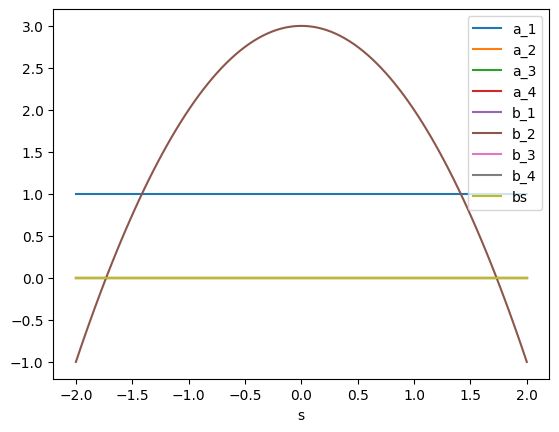

In [90]:
#start from multipole coeefficients a_n(s)=a1,a2,... and b_n(s)
a_coeffs = [1, 0, 0, 0]
b_coeffs = [0,"-s**2+3",0, 0]
#get scalar potential
expansion=bpmeth.FieldExpansion(a=a_coeffs, b=b_coeffs)
expansion.plot_components()
plt.xlabel('s')


Scalar potential phi(x,y,s): x*y**3/3 + x*y*(3 - s**2) + x
Scalar potential phi at (0.4,0.2,0.5): 0.6210666666666667


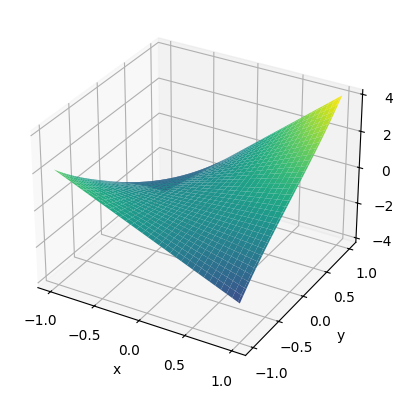

In [91]:
phi=expansion.get_phi()
print("Scalar potential phi(x,y,s):", phi)
#define x,y,s axes to convert the symbolic expression of phi into a numerical array
xa= np.linspace(-1,1,101)
ya=np.linspace(-1,1,101)
sa=np.linspace(0,1,101)
XYS=(x,y,s)

phi_func = lambdify(XYS, phi, 'numpy')
print("Scalar potential phi at (0.4,0.2,0.5):", phi_func(0.4,0.2,0.5))

#make a 3d plot of phi as a function of x and y for a fixed s

X, Y = np.meshgrid(xa, ya)
P = phi_func(X, Y, 0.5)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, P, cmap='viridis')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('phi(x,y,s=0.5)')
plt.show()

In [92]:
#B=expansion.create_fieldmap(xarr=xa,yarr=ya,sarr=sa, filename=None)
#B.plot()

In [93]:
# Get analytical B field functions
Bx_func, By_func, Bs_func = expansion.get_Bfield(lambdify=True)
#print("Bx:", Bx_func, "By:", By_func, "Bs:", Bs_func)
# Evaluate on grid
X,Y,S = np.meshgrid(xa, ya, sa, indexing='ij')
Bx_ana = Bx_func(X, Y, S)
By_ana = By_func(X, Y, S)
Bs_ana = Bs_func(X, Y, S)

Ax: <numpy.vectorize object at 0x7f7db3936530> Ay: <numpy.vectorize object at 0x7f7db3934e10> As: <numpy.vectorize object at 0x7f7db3935130>


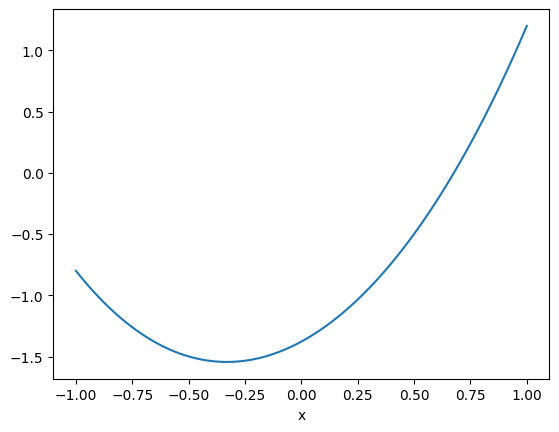

In [94]:
Ax, Ay, As = expansion.get_A(lambdify=True)
print("Ax:", Ax, "Ay:", Ay, "As:", As)
Ax_ana = Ax(X, Y, S)
Ay_ana = Ay(X, Y, S)
As_ana = As(X, Y, S)

#plot As as a function of x for s=0 and y=0
plt.plot(xa, As_ana[2, :, 10])
plt.xlabel('x')

plt.show()

Max difference in Bx: 0.039867333333358346
Max difference in By: 0.02999999999999714
Max difference in Bs: 0.019999999999997797


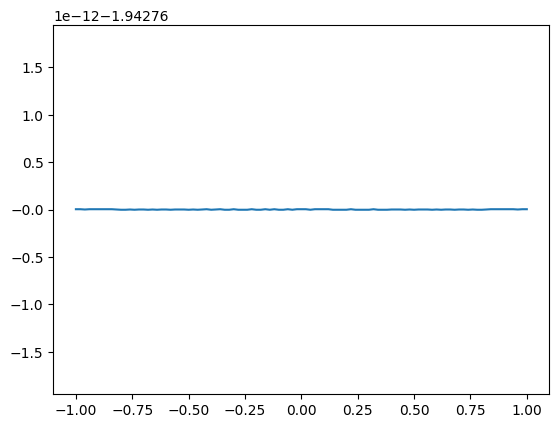

In [95]:
#then take the curl of A from finite differences and compare with the original B field
def curl_3d(Ax, Ay, Az, dx, dy, dz):
  
    # Compute partial derivatives
    dAx_dy = np.gradient(Ax, dy, axis=1)
    dAx_dz = np.gradient(Ax, dz, axis=2)
    dAy_dx = np.gradient(Ay, dx, axis=0)
    dAy_dz = np.gradient(Ay, dz, axis=2)
    dAz_dx = np.gradient(Az, dx, axis=0)
    dAz_dy = np.gradient(Az, dy, axis=1)
    
    # Curl components
    curl_x = dAz_dy - dAy_dz
    curl_y = dAx_dz - dAz_dx
    curl_z = dAy_dx - dAx_dy
    
    return curl_x, curl_y, curl_z

# Compute spacings
dx = xa[1] - xa[0]
dy = ya[1] - ya[0]
ds = sa[1] - sa[0]
# Compute curl
curl_Ax, curl_Ay, curl_As = curl_3d(Ax_ana, Ay_ana, As_ana, dx, dy, ds)

# Compare with computed curl
print("Max difference in Bx:", np.max(np.abs(curl_Ax - Bx_ana)))
print("Max difference in By:", np.max(np.abs(curl_Ay - By_ana)))
print("Max difference in Bs:", np.max(np.abs(curl_As - Bs_ana)))
plt.plot(xa, curl_Ax[:, 5,2], label='Curl of A')


Now we can go back to the multipole components using 

$a_{n}(s) = \left. \partial^{n-1}_x B_x(x,y,s) \right|_{x=y=0}$

and

$ b_{n}(s) = \left. \partial^{n-1}_x B_y(x,y,s) \right|_{x=y=0} $

In [96]:
def derivativesFromField(x, B_i, max_order): #i= x or y, B_i is the 3d array of the field component evaluated on the grid, max_order is the maximum order of derivative to compute
    dBvector=np.zeros((max_order+1, len(B_i),len(sa)))
    dBvector[0,:,:] = B_i[:, B_i.shape[1]//2, :] #take the field at y=0, keep x,s dependence
    for i in range(1,max_order+1):
        dBvector[i,:,:]=np.gradient(dBvector[i-1,:,:], x, axis=0)
    return dBvector
max_order = 4
idx_zero = np.argmin(np.abs(xa))

dBxvector=derivativesFromField(xa, Bx_ana, max_order)
dByvector=derivativesFromField(xa, By_ana, max_order)


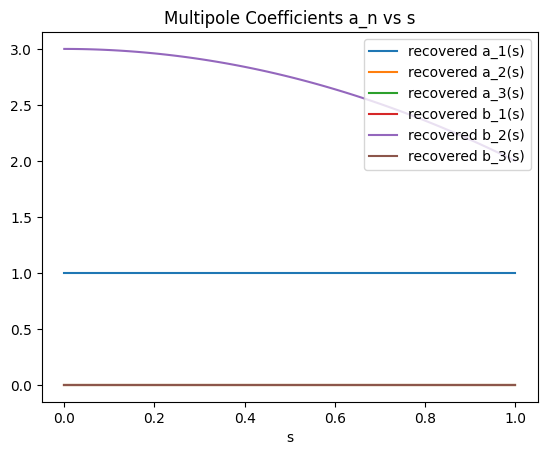

In [ ]:
a_nnew=np.zeros((len(a_coeffs),len(sa)))
b_nnew=np.zeros((len(b_coeffs),len(sa)))
a_nnew[:,:]=dBxvector[:max_order,idx_zero,:]
b_nnew[:,:]=dByvector[:max_order,idx_zero,:]


plt.plot(sa, a_nnew[0,:], label='recovered a_1(s)')
plt.plot(sa, a_nnew[1,:], label='recovered a_2(s)')
plt.plot(sa, a_nnew[2,:], label='recovered a_3(s)')
plt.plot(sa, b_nnew[0,:], label='recovered b_1(s)')
plt.plot(sa, b_nnew[1,:], label='recovered b_2(s)')
plt.plot(sa, b_nnew[2,:], label='recovered b_3(s)')
plt.xlabel('s')
plt.legend()
plt.title('Multipole Coefficients a_n vs s')
plt.show()
#the reconstruction works: mind the different s axis 